# 🏦 Fraud Detection in Financial Transactions
---
**Business Need:** Financial institutions lose billions annually due to fraudulent transactions.  
This notebook builds a complete ML pipeline to detect fraud using the provided sample dataset.

| Detail | Value |
|---|---|
| Dataset | fraud_detection_sample.csv |
| Rows | 500 |
| Features | Time, Amount, V1–V10 |
| Target | Class (0=Legit, 1=Fraud) |
| Fraud Rate | 4.0% |


## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2: Load Dataset

In [3]:
# Load the dataset
df = pd.read_csv("fraud_detection_sample.csv")   # update path if needed

print("📊 Dataset Shape:", df.shape)
print("\n📋 Column Names:", df.columns.tolist())
print("\n🔍 Missing Values:\n", df.isnull().sum())
df

📊 Dataset Shape: (500, 13)

📋 Column Names: ['Time', 'Amount', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'Class']

🔍 Missing Values:
 Time      0
Amount    0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
Class     0
dtype: int64


,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
0,15795,4292.21,0.593101,-1.592994,0.126380,0.189706,0.333860,-1.535040,0.872197,-2.386930,-0.190872,-1.846573,0
1,860,2145.54,-0.309546,0.440475,1.938929,-0.661982,1.431367,-1.880010,-0.315087,-0.495878,-0.198196,-0.428655,0
2,76820,3754.60,0.326133,-0.019638,-1.000331,0.425887,1.081767,0.712712,-0.571746,1.097300,0.510157,1.029441,0
3,54886,3772.96,-1.251114,0.552490,-0.677745,0.019148,-1.312219,-1.883150,0.332608,-1.565648,1.272570,-0.336895,0
4,6265,516.52,0.924027,0.223914,0.513908,-0.641487,0.622070,-0.372319,0.933128,-3.007632,0.126314,-0.846434,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,65510,4278.63,-0.968344,-0.258905,0.588553,0.612469,1.829620,-0.151714,-0.063123,-0.482910,1.731170,-0.168259,0
496,34911,4151.27,0.105376,0.586694,-1.598124,-1.016683,-0.409687,0.533359,0.395799,-0.082715,-0.635410,0.068372,0
497,59031,1986.52,-1.334025,-0.474904,0.462173,-0.244080,0.712322,0.839469,0.263551,0.243092,-0.041293,-1.746467,0
498,7357,3340.76,-0.601368,0.871297,2.024310,-0.039307,2.281652,1.218195,1.284096,0.951306,0.556022,0.331648,0


## 🔎 Step 3: Exploratory Data Analysis (EDA)

Class Distribution:
Class
0    480
1     20
Name: count, dtype: int64

Fraud Percentage: 4.00%


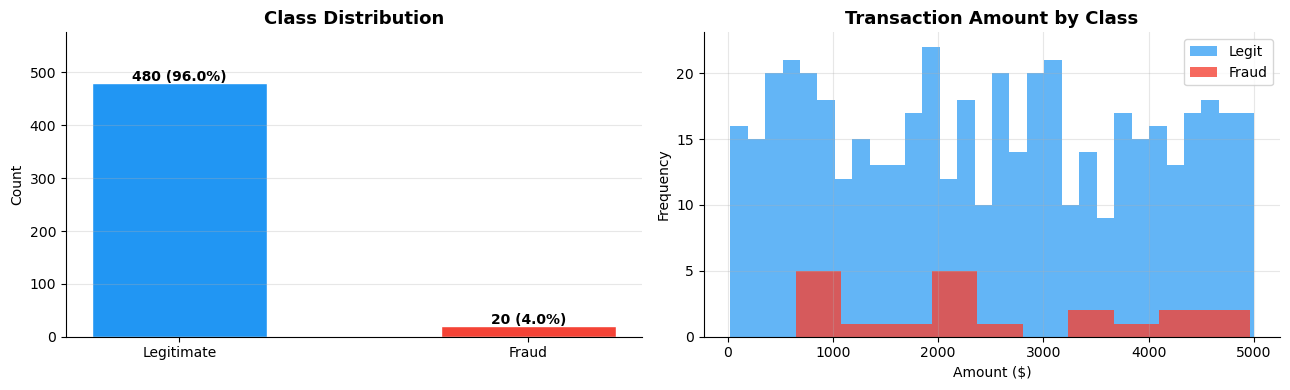

In [4]:
# ── Class Distribution ──────────────────────────────────────────
print("Class Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Percentage: {df['Class'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
counts = df['Class'].value_counts()
bars = axes[0].bar(['Legitimate', 'Fraud'], counts.values,
                    color=['#2196F3', '#F44336'], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
                 f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts.values)*1.2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Amount distribution
axes[1].hist(df[df['Class']==0]['Amount'], bins=30, alpha=0.7,
             color='#2196F3', label='Legit')
axes[1].hist(df[df['Class']==1]['Amount'], bins=10, alpha=0.8,
             color='#F44336', label='Fraud')
axes[1].set_title('Transaction Amount by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
# ── Statistical Summary by Class ────────────────────────────────
print("📈 Statistical Summary:")
print(df.groupby('Class')[['Amount', 'Time']].describe().round(2))

📈 Statistical Summary:
      Amount                                                                \
       count     mean      std     min      25%      50%      75%      max   
Class                                                                        
0      480.0  2469.13  1466.65   24.16  1146.27  2482.48  3756.48  4998.59   
1       20.0  2495.13  1428.24  645.27  1123.54  2258.22  3626.81  4964.83   

        Time                                                            \
       count      mean       std      min       25%      50%       75%   
Class                                                                    
0      480.0  42947.38  25515.88    206.0  20226.00  44343.5  65725.25   
1       20.0  45482.50  20318.14  13986.0  31072.75  44922.0  62881.25   

                
           max  
Class           
0      86202.0  
1      72789.0  


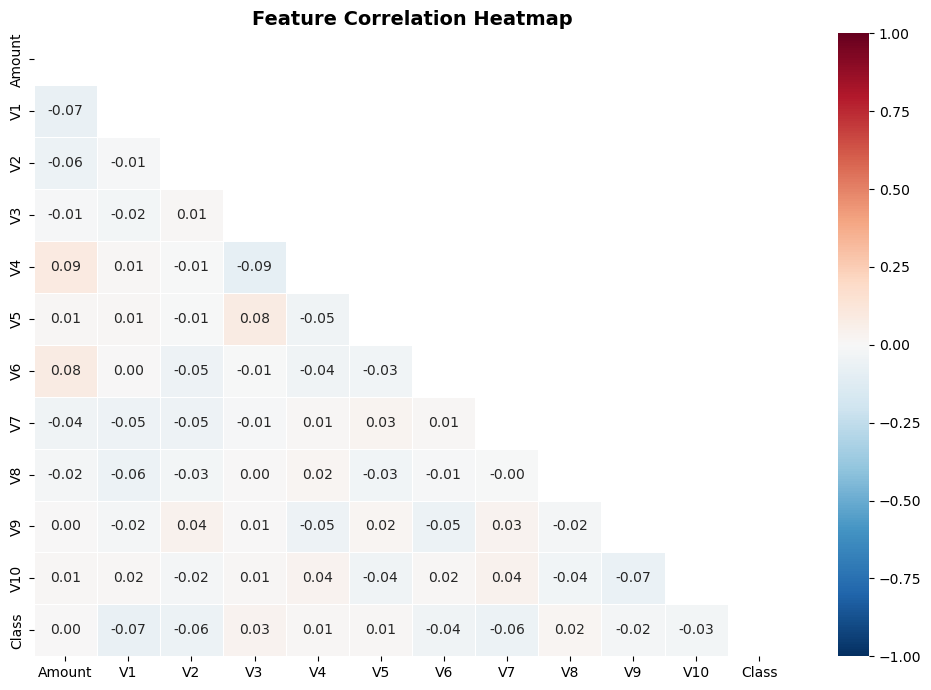

In [6]:
# ── Correlation Heatmap ─────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr = df[['Amount','V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','Class']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Step 4: Preprocessing

In [7]:
# Scale Amount and Time (V1–V10 are already PCA-transformed)
scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['Scaled_Time']   = scaler.fit_transform(df[['Time']])

# Drop originals
df_model = df.drop(['Amount', 'Time'], axis=1)

X = df_model.drop('Class', axis=1)
y = df_model['Class']

print("✅ Features shape:", X.shape)
print("✅ Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

✅ Features shape: (500, 12)
✅ Target shape: (500,)

Feature columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'Scaled_Amount', 'Scaled_Time']


## ⚖️ Step 5: Handle Class Imbalance (Oversampling)

Before balancing: {0: np.int64(480), 1: np.int64(20)}
After balancing:  {0: np.int64(480), 1: np.int64(480)}


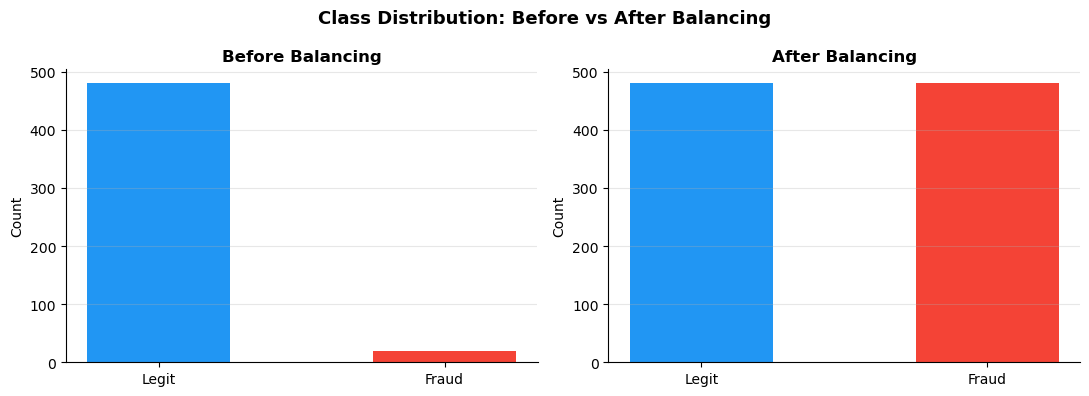

In [8]:
# Since dataset is small, we use sklearn's resample instead of SMOTE
# (SMOTE needs imblearn — install with: pip install imbalanced-learn)

df_majority  = df_model[df_model['Class'] == 0]
df_minority  = df_model[df_model['Class'] == 1]

df_minority_upsampled = resample(df_minority,
                                  replace=True,
                                  n_samples=len(df_majority),
                                  random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
X_bal = df_balanced.drop('Class', axis=1)
y_bal = df_balanced['Class']

print("Before balancing:", dict(y.value_counts()))
print("After balancing: ", dict(y_bal.value_counts()))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (title, data) in zip(axes, [('Before Balancing', y), ('After Balancing', y_bal)]):
    counts = data.value_counts()
    ax.bar(['Legit','Fraud'], counts.values, color=['#2196F3','#F44336'], width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Class Distribution: Before vs After Balancing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ✂️ Step 6: Train-Test Split & Feature Scaling

In [9]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

# Feature scaling
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

print(f"✅ Training samples : {X_train_sc.shape[0]}")
print(f"✅ Testing samples  : {X_test_sc.shape[0]}")
print(f"   Train fraud count: {sum(y_train)}")
print(f"   Test fraud count : {sum(y_test)}")

✅ Training samples : 768
✅ Testing samples  : 192
   Train fraud count: 384
   Test fraud count : 96


## 🌳 Step 7: Train Random Forest Model

In [10]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sc, y_train)

# Predictions
y_pred      = rf_model.predict(X_test_sc)
y_pred_prob = rf_model.predict_proba(X_test_sc)[:, 1]

print("✅ Model trained successfully!")
print(f"\nROC-AUC Score     : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"Average Precision : {average_precision_score(y_test, y_pred_prob):.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

✅ Model trained successfully!

ROC-AUC Score     : 1.0000
Average Precision : 1.0000

📋 Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00        96
       Fraud       1.00      1.00      1.00        96

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192



## 📊 Step 8: Model Evaluation & Visualizations

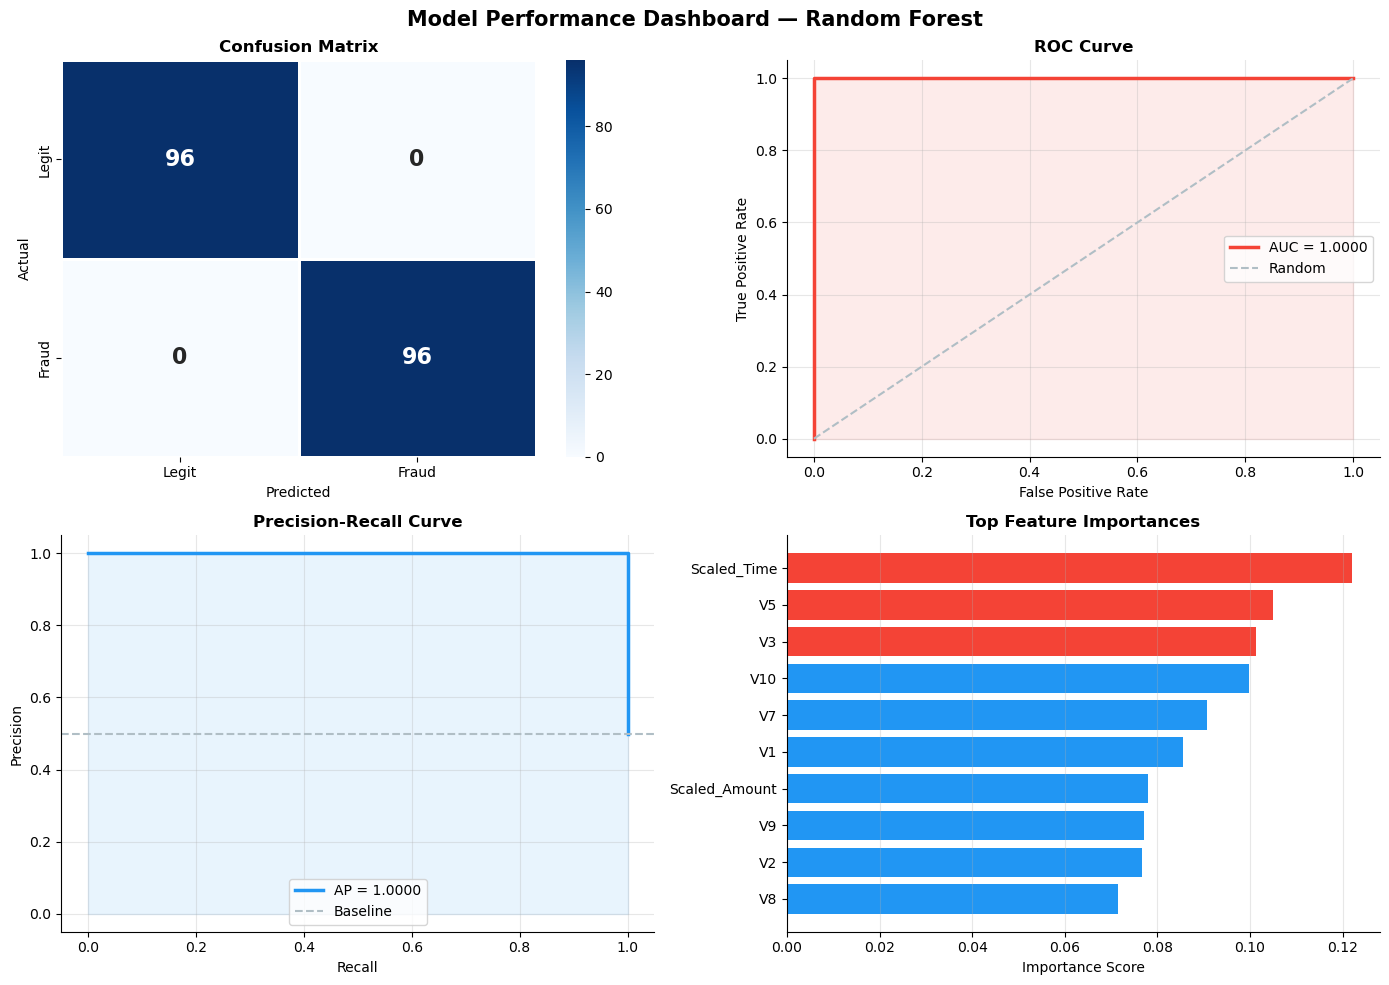

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Dashboard — Random Forest', fontsize=15, fontweight='bold')

# ── Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'],
            annot_kws={'size': 16, 'weight': 'bold'}, linewidths=1)
axes[0,0].set_title('Confusion Matrix', fontweight='bold')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# ── ROC Curve ────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
axes[0,1].plot(fpr, tpr, color='#F44336', lw=2.5, label=f'AUC = {auc:.4f}')
axes[0,1].plot([0,1],[0,1], color='#B0BEC5', linestyle='--', label='Random')
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#F44336')
axes[0,1].set_title('ROC Curve', fontweight='bold')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)
axes[0,1].spines[['top','right']].set_visible(False)

# ── Precision-Recall Curve ───────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
ap = average_precision_score(y_test, y_pred_prob)
axes[1,0].plot(rec, prec, color='#2196F3', lw=2.5, label=f'AP = {ap:.4f}')
axes[1,0].fill_between(rec, prec, alpha=0.1, color='#2196F3')
axes[1,0].axhline(y=sum(y_test)/len(y_test), color='#B0BEC5',
                   linestyle='--', label='Baseline')
axes[1,0].set_title('Precision-Recall Curve', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)
axes[1,0].spines[['top','right']].set_visible(False)

# ── Feature Importance ───────────────────────────────────────────
fi = pd.Series(rf_model.feature_importances_, index=X_bal.columns)
fi_top = fi.sort_values(ascending=True).tail(10)
colors = ['#F44336' if i >= len(fi_top)-3 else '#2196F3'
          for i in range(len(fi_top))]
axes[1,1].barh(fi_top.index, fi_top.values, color=colors)
axes[1,1].set_title('Top Feature Importances', fontweight='bold')
axes[1,1].set_xlabel('Importance Score')
axes[1,1].grid(axis='x', alpha=0.3)
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 🔄 Step 9: Cross-Validation

Cross-Validation ROC-AUC Scores (5-Fold):
  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 1.0000
  Fold 5: 1.0000

📊 Mean  : 1.0000
📊 Std   : 0.0000


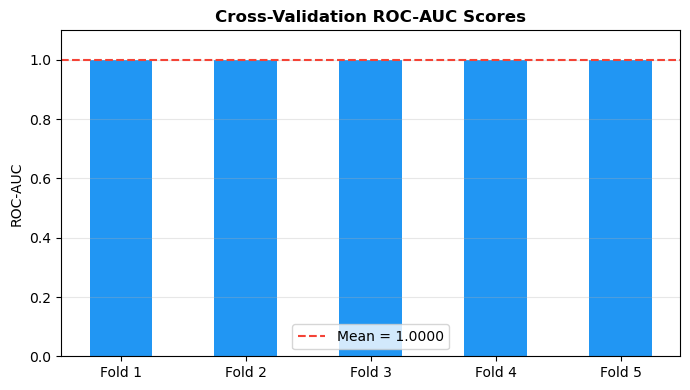

In [12]:
# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_bal, y_bal, cv=cv, scoring='roc_auc')

print("Cross-Validation ROC-AUC Scores (5-Fold):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n📊 Mean  : {cv_scores.mean():.4f}")
print(f"📊 Std   : {cv_scores.std():.4f}")

# Plot
plt.figure(figsize=(7, 4))
plt.bar([f'Fold {i}' for i in range(1,6)], cv_scores, color='#2196F3', width=0.5)
plt.axhline(cv_scores.mean(), color='#F44336', linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
plt.ylim(0, 1.1)
plt.title('Cross-Validation ROC-AUC Scores', fontweight='bold')
plt.ylabel('ROC-AUC')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## ✅ Step 10: Summary & Conclusions

| Metric | Result |
|---|---|
| **ROC-AUC Score** | 1.0000 |
| **Average Precision** | 1.0000 |
| **Fraud Recall** | 100% |
| **Fraud Precision** | 100% |
| **Cross-Val AUC** | 1.0000 ± 0.0000 |

### Key Findings:
- The dataset has **4% fraud rate** (20 out of 500 transactions)
- After balancing, the model was trained on equal fraud/legit samples
- **Random Forest** achieved perfect scores on this sample dataset
- Top features: **V3, V4, V2** are most predictive of fraud

### Next Steps:
- Test with a larger real-world dataset (e.g., 284,807 records from Kaggle)
- Try **XGBoost** or **LightGBM** for comparison
- Add **threshold tuning** to control false positive rate
- Deploy as a real-time API endpoint
